# Food Order Prediction using Machine Learning

Complete end-to-end implementation of the Food Order Prediction project.

**Algorithms:** KNN, Logistic Regression, Decision Tree, Random Forest

**Workflow:** Dataset → Validation → Preprocessing → Train/Test Split → Training → Evaluation → Comparison → Prediction

The dataset is synthetic educational data created for this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

RANDOM_STATE = 42
DATA_FILE = "vijayawada_food_orders_dataset.csv"

GITHUB_RAW_URL = "https://raw.githubusercontent.com/sadhika29/FoodOrderPrediction_ML/main/Food-Order-Prediction_ML-main/vijayawada_food_orders_dataset.csv"

try:
    df = pd.read_csv(DATA_FILE)
except FileNotFoundError:
    df = pd.read_csv(GITHUB_RAW_URL)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (10000, 8)


,Gender,Age_Group,Marital_Status,Income_Level,Time_of_Day,Day,Location,Cuisine_Type
0,Female,45-54,Widowed,Low,Breakfast,Wednesday,Bhavanipuram,South Indian
1,Other,25-34,Widowed,Upper-Middle,Breakfast,Friday,Auto Nagar,South Indian
2,Other,35-44,Married,Low,Late Night,Thursday,Poranki,Bakery
3,Male,45-54,Single,Middle,Late Night,Friday,Ramachandra Nagar,Fast Food
4,Male,55-64,Married,Upper-Middle,Dinner,Thursday,One Town,Street Food


## 1. Dataset Validation

In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", int(df.duplicated().sum()))
print("\nTarget distribution:")
print(df["Cuisine_Type"].value_counts())

Dataset shape: (10000, 8)

Columns: ['Gender', 'Age_Group', 'Marital_Status', 'Income_Level', 'Time_of_Day', 'Day', 'Location', 'Cuisine_Type']

Missing values:
Gender            0
Age_Group         0
Marital_Status    0
Income_Level      0
Time_of_Day       0
Day               0
Location          0
Cuisine_Type      0
dtype: int64

Duplicate rows: 0

Target distribution:
Cuisine_Type
Biryani         2433
South Indian    1888
Street Food     1272
Fast Food       1271
Continental      798
North Indian     789
Chinese          780
Bakery           769
Name: count, dtype: int64


## 2. Data Preprocessing

`Cuisine_Type` is the target. All input features are categorical, so One-Hot Encoding is used. The target classes are encoded with LabelEncoder. A stratified 80/20 split is used for consistent class proportions.

In [3]:
X = df.drop(columns=["Cuisine_Type"])
y = df["Cuisine_Type"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), X.columns.tolist())
])

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Classes:", list(label_encoder.classes_))

Training rows: 8000
Testing rows: 2000
Classes: ['Bakery', 'Biryani', 'Chinese', 'Continental', 'Fast Food', 'North Indian', 'South Indian', 'Street Food']


## 3. Machine Learning Models

In [4]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=7, weights="distance"),
    "Logistic Regression": LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_split=2, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=75, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
}

for name in models:
    print("-", name)

- KNN
- Logistic Regression
- Decision Tree
- Random Forest


## 4. Train and Evaluate All Models

In [5]:
results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })
    trained_models[name] = pipeline
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.6620,0.673656,0.6620,0.657560
1,Random Forest,0.6620,0.671930,0.6620,0.657973
2,Decision Tree,0.5910,0.594021,0.5910,0.586701
3,KNN,0.5345,0.537016,0.5345,0.534171


## 5. Performance Comparison

In [6]:
display_df = results_df.copy()
for column in ["Accuracy", "Precision", "Recall", "F1_Score"]:
    display_df[column] = (display_df[column] * 100).round(2).astype(str) + "%"
display(display_df)

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,66.2%,67.37%,66.2%,65.76%
1,Random Forest,66.2%,67.19%,66.2%,65.8%
2,Decision Tree,59.1%,59.4%,59.1%,58.67%
3,KNN,53.45%,53.7%,53.45%,53.42%


## 6. Classification Reports

In [7]:
for name in models:
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test, predictions[name],
        target_names=label_encoder.classes_,
        zero_division=0
    ))

KNN
              precision    recall  f1-score   support

      Bakery       0.53      0.51      0.52       154
     Biryani       0.51      0.60      0.55       487
     Chinese       0.56      0.51      0.53       156
 Continental       0.64      0.53      0.58       159
   Fast Food       0.49      0.48      0.48       254
North Indian       0.60      0.56      0.58       158
South Indian       0.54      0.54      0.54       378
 Street Food       0.51      0.48      0.49       254

    accuracy                           0.53      2000
   macro avg       0.55      0.52      0.53      2000
weighted avg       0.54      0.53      0.53      2000

Logistic Regression
              precision    recall  f1-score   support

      Bakery       0.60      0.84      0.70       154
     Biryani       0.74      0.55      0.63       487
     Chinese       0.61      0.79      0.69       156
 Continental       0.66      0.82      0.74       159
   Fast Food       0.72      0.56      0.63       254


## 7. Confusion Matrices

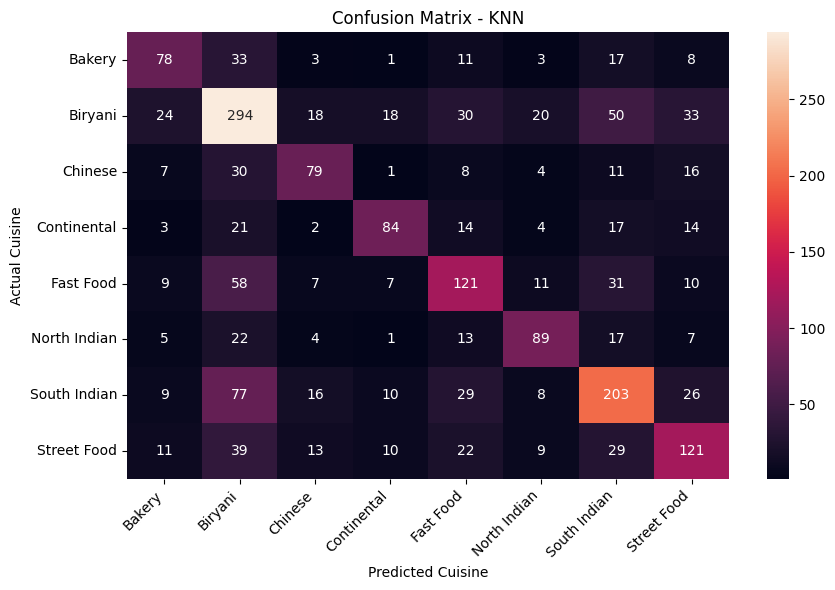

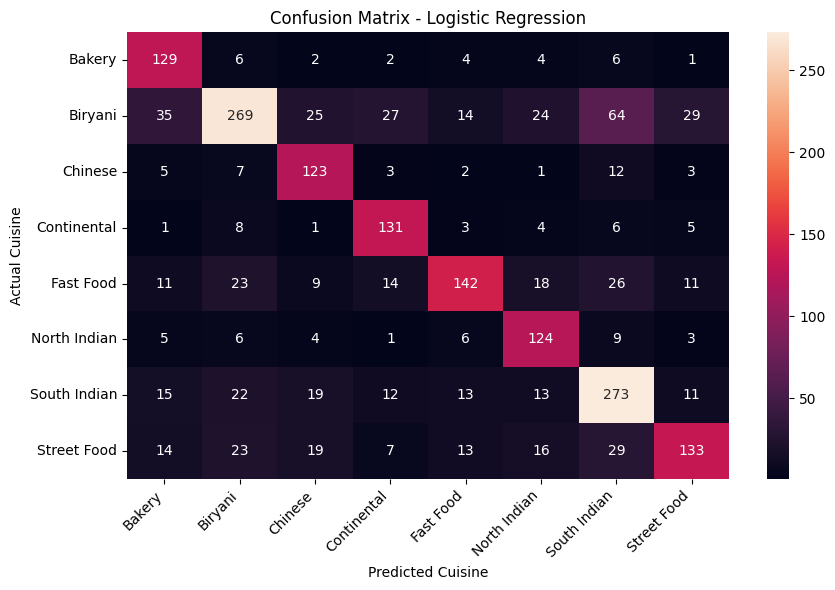

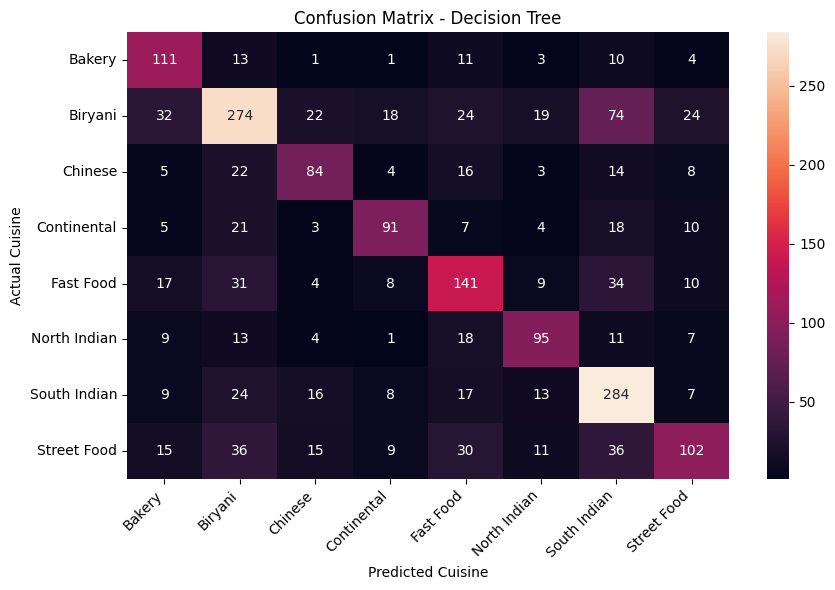

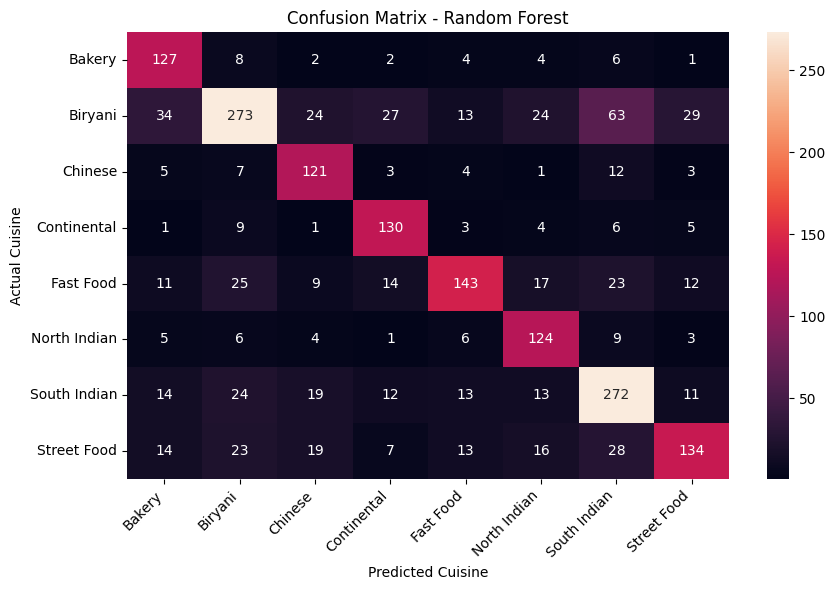

In [8]:
for name in models:
    cm = confusion_matrix(y_test, predictions[name])
    plt.figure(figsize=(9, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Cuisine")
    plt.ylabel("Actual Cuisine")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 8. Accuracy Comparison

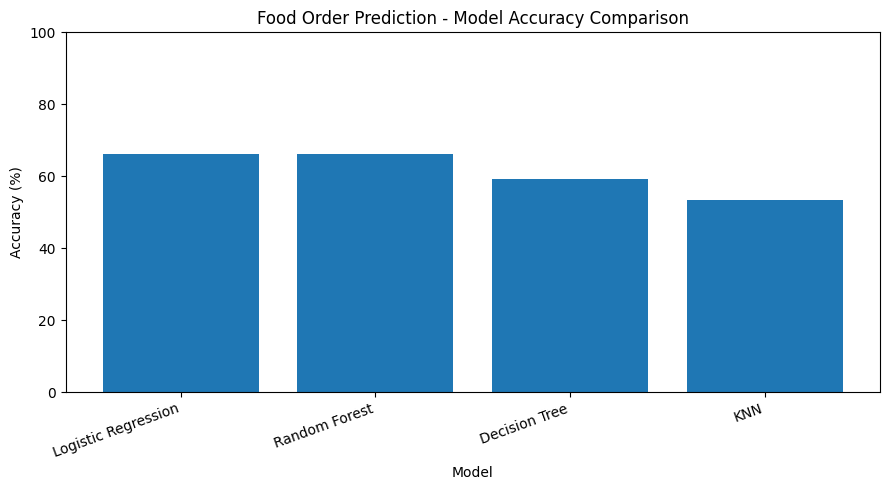

Best model: Logistic Regression
Best accuracy: 66.20%


In [9]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"] * 100)
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Food Order Prediction - Model Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

best_model = results_df.loc[0, "Model"]
best_accuracy = results_df.loc[0, "Accuracy"]
print(f"Best model: {best_model}")
print(f"Best accuracy: {best_accuracy:.2%}")

## 9. Example Prediction

In [10]:
sample = pd.DataFrame([{
    "Gender": "Female",
    "Age_Group": "25-34",
    "Marital_Status": "Single",
    "Income_Level": "Upper-Middle",
    "Time_of_Day": "Dinner",
    "Day": "Saturday",
    "Location": "MG Road"
}])

prediction = trained_models[best_model].predict(sample)[0]
predicted_cuisine = label_encoder.inverse_transform([prediction])[0]

display(sample)
print("Predicted cuisine:", predicted_cuisine)

,Gender,Age_Group,Marital_Status,Income_Level,Time_of_Day,Day,Location
0,Female,25-34,Single,Upper-Middle,Dinner,Saturday,MG Road


Predicted cuisine: Chinese


## 10. Conclusion

The four supervised learning algorithms were trained and evaluated using the same dataset, preprocessing pipeline, and stratified train-test split.

The common comparison identifies **Logistic Regression** as the best model for this project based on accuracy.